# Grover's Search Algorithm — Qiskit Implementation

**10-qubit search space (1024 elements)**  
Marked states: `0110011010` and `1101010001`

This notebook implements Grover's algorithm from scratch using Qiskit quantum gates.
No built-in `qiskit.algorithms.Grover` is used.

---
### Components
| Function | Role |
|---|---|
| `build_oracle()` | Phase-flip oracle for arbitrary target bit-strings |
| `build_diffusion()` | Grover diffusion operator (H → U0 → H) |
| `build_grover_circuit()` | Assembles the full circuit |
| `run_grover()` | Simulates and returns measurement counts |

In [1]:
# Install dependencies (run once)
# !pip install qiskit qiskit-aer matplotlib

In [2]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

## 1 · Oracle

For each target bit-string `t`:
1. Apply **X** on qubits where `t` has a `'0'` → maps `|t⟩` to `|11…1⟩`
2. Apply **multi-controlled Z** → flips the phase of `|11…1⟩`
3. Undo the X gates

The MCZ is decomposed as `H · MCX · H` on the target qubit.

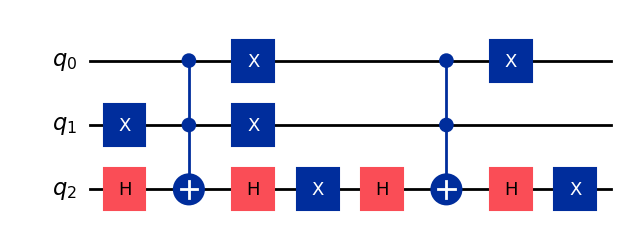

In [3]:
def build_oracle(n: int, targets: list) -> QuantumCircuit:
    qr = QuantumRegister(n, "q")
    oracle = QuantumCircuit(qr, name="Oracle")

    for target in targets:
        assert len(target) == n
        # Qubit 0 = LSB; bit-string index i → qubit (n-1-i)
        zero_positions = [n - 1 - i for i, bit in enumerate(target) if bit == "0"]

        for q in zero_positions:
            oracle.x(qr[q])

        # Multi-controlled Z via H · MCX · H
        oracle.h(qr[n - 1])
        oracle.mcx(list(range(n - 1)), n - 1)
        oracle.h(qr[n - 1])

        for q in zero_positions:
            oracle.x(qr[q])

    return oracle

# Quick sanity-check: draw the oracle for 3 qubits
build_oracle(3, ["101", "010"]).draw("mpl")

## 2 · Diffusion Operator

$$D = H^{\otimes n}\,U_0\,H^{\otimes n}$$

$U_0$ flips the phase of every state **except** $|0\cdots 0\rangle$.

Implementation of $U_0$:
- Apply **X** on all qubits → `|0…0⟩` becomes `|1…1⟩`
- Multi-controlled Z on `|1…1⟩`
- Undo X

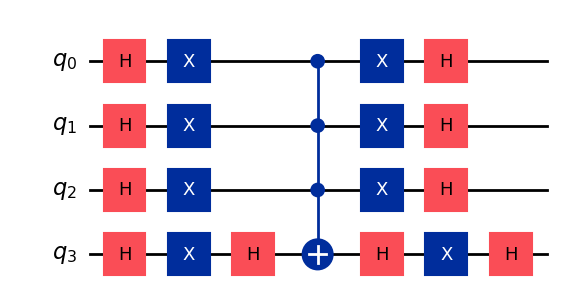

In [4]:
def build_diffusion(n: int) -> QuantumCircuit:
    qr = QuantumRegister(n, "q")
    diff = QuantumCircuit(qr, name="Diffusion")

    diff.h(qr)
    diff.x(qr)
    diff.h(qr[n - 1])
    diff.mcx(list(range(n - 1)), n - 1)
    diff.h(qr[n - 1])
    diff.x(qr)
    diff.h(qr)

    return diff

build_diffusion(4).draw("mpl")

## 3 · Full Grover Circuit

In [5]:
def build_grover_circuit(n: int, targets: list, iterations: int) -> QuantumCircuit:
    qc = QuantumCircuit(QuantumRegister(n, "q"), ClassicalRegister(n, "c"))

    # Equal superposition
    qc.h(range(n))
    qc.barrier()

    oracle    = build_oracle(n, targets)
    diffusion = build_diffusion(n)

    for _ in range(iterations):
        qc.compose(oracle,    inplace=True)
        qc.barrier()
        qc.compose(diffusion, inplace=True)
        qc.barrier()

    qc.measure(range(n), range(n))
    return qc

## 4 · Simulate

In [6]:
def run_grover(circuit: QuantumCircuit, shots: int = 2048) -> dict:
    simulator = AerSimulator()
    job    = simulator.run(circuit, shots=shots)
    result = job.result()
    return result.get_counts(circuit)

## 5 · Run & Plot

Theoretical optimal iterations for $N=1024$, $M=2$:
$$k^* = \left\lfloor \frac{\pi}{4}\sqrt{\frac{N}{M}} \right\rceil = 18$$

In [7]:
# ── Configuration ────────────────────────────────────────────────
N_QUBITS = 10
SHOTS    = 2048
targets  = ["0110011010", "1101010001"]

k_optimal = max(1, round((math.pi / 4) * math.sqrt(2**N_QUBITS / len(targets))))
print(f"Optimal iterations: {k_optimal}")

iteration_counts = sorted(set([1, 3, 5, 10, k_optimal]))

# ── Run ──────────────────────────────────────────────────────────
all_counts = {}
for k in iteration_counts:
    print(f"k={k} …", end=" ", flush=True)
    circuit = build_grover_circuit(N_QUBITS, targets, k)
    counts  = run_grover(circuit, shots=SHOTS)
    all_counts[k] = counts
    prob = sum(counts.get(t, 0) for t in targets) / SHOTS * 100
    print(f"P(marked) = {prob:.1f}%")

Optimal iterations: 18
k=1 … P(marked) = 1.3%
k=3 … P(marked) = 9.9%
k=5 … P(marked) = 20.5%
k=10 … P(marked) = 66.1%
k=18 … P(marked) = 99.6%


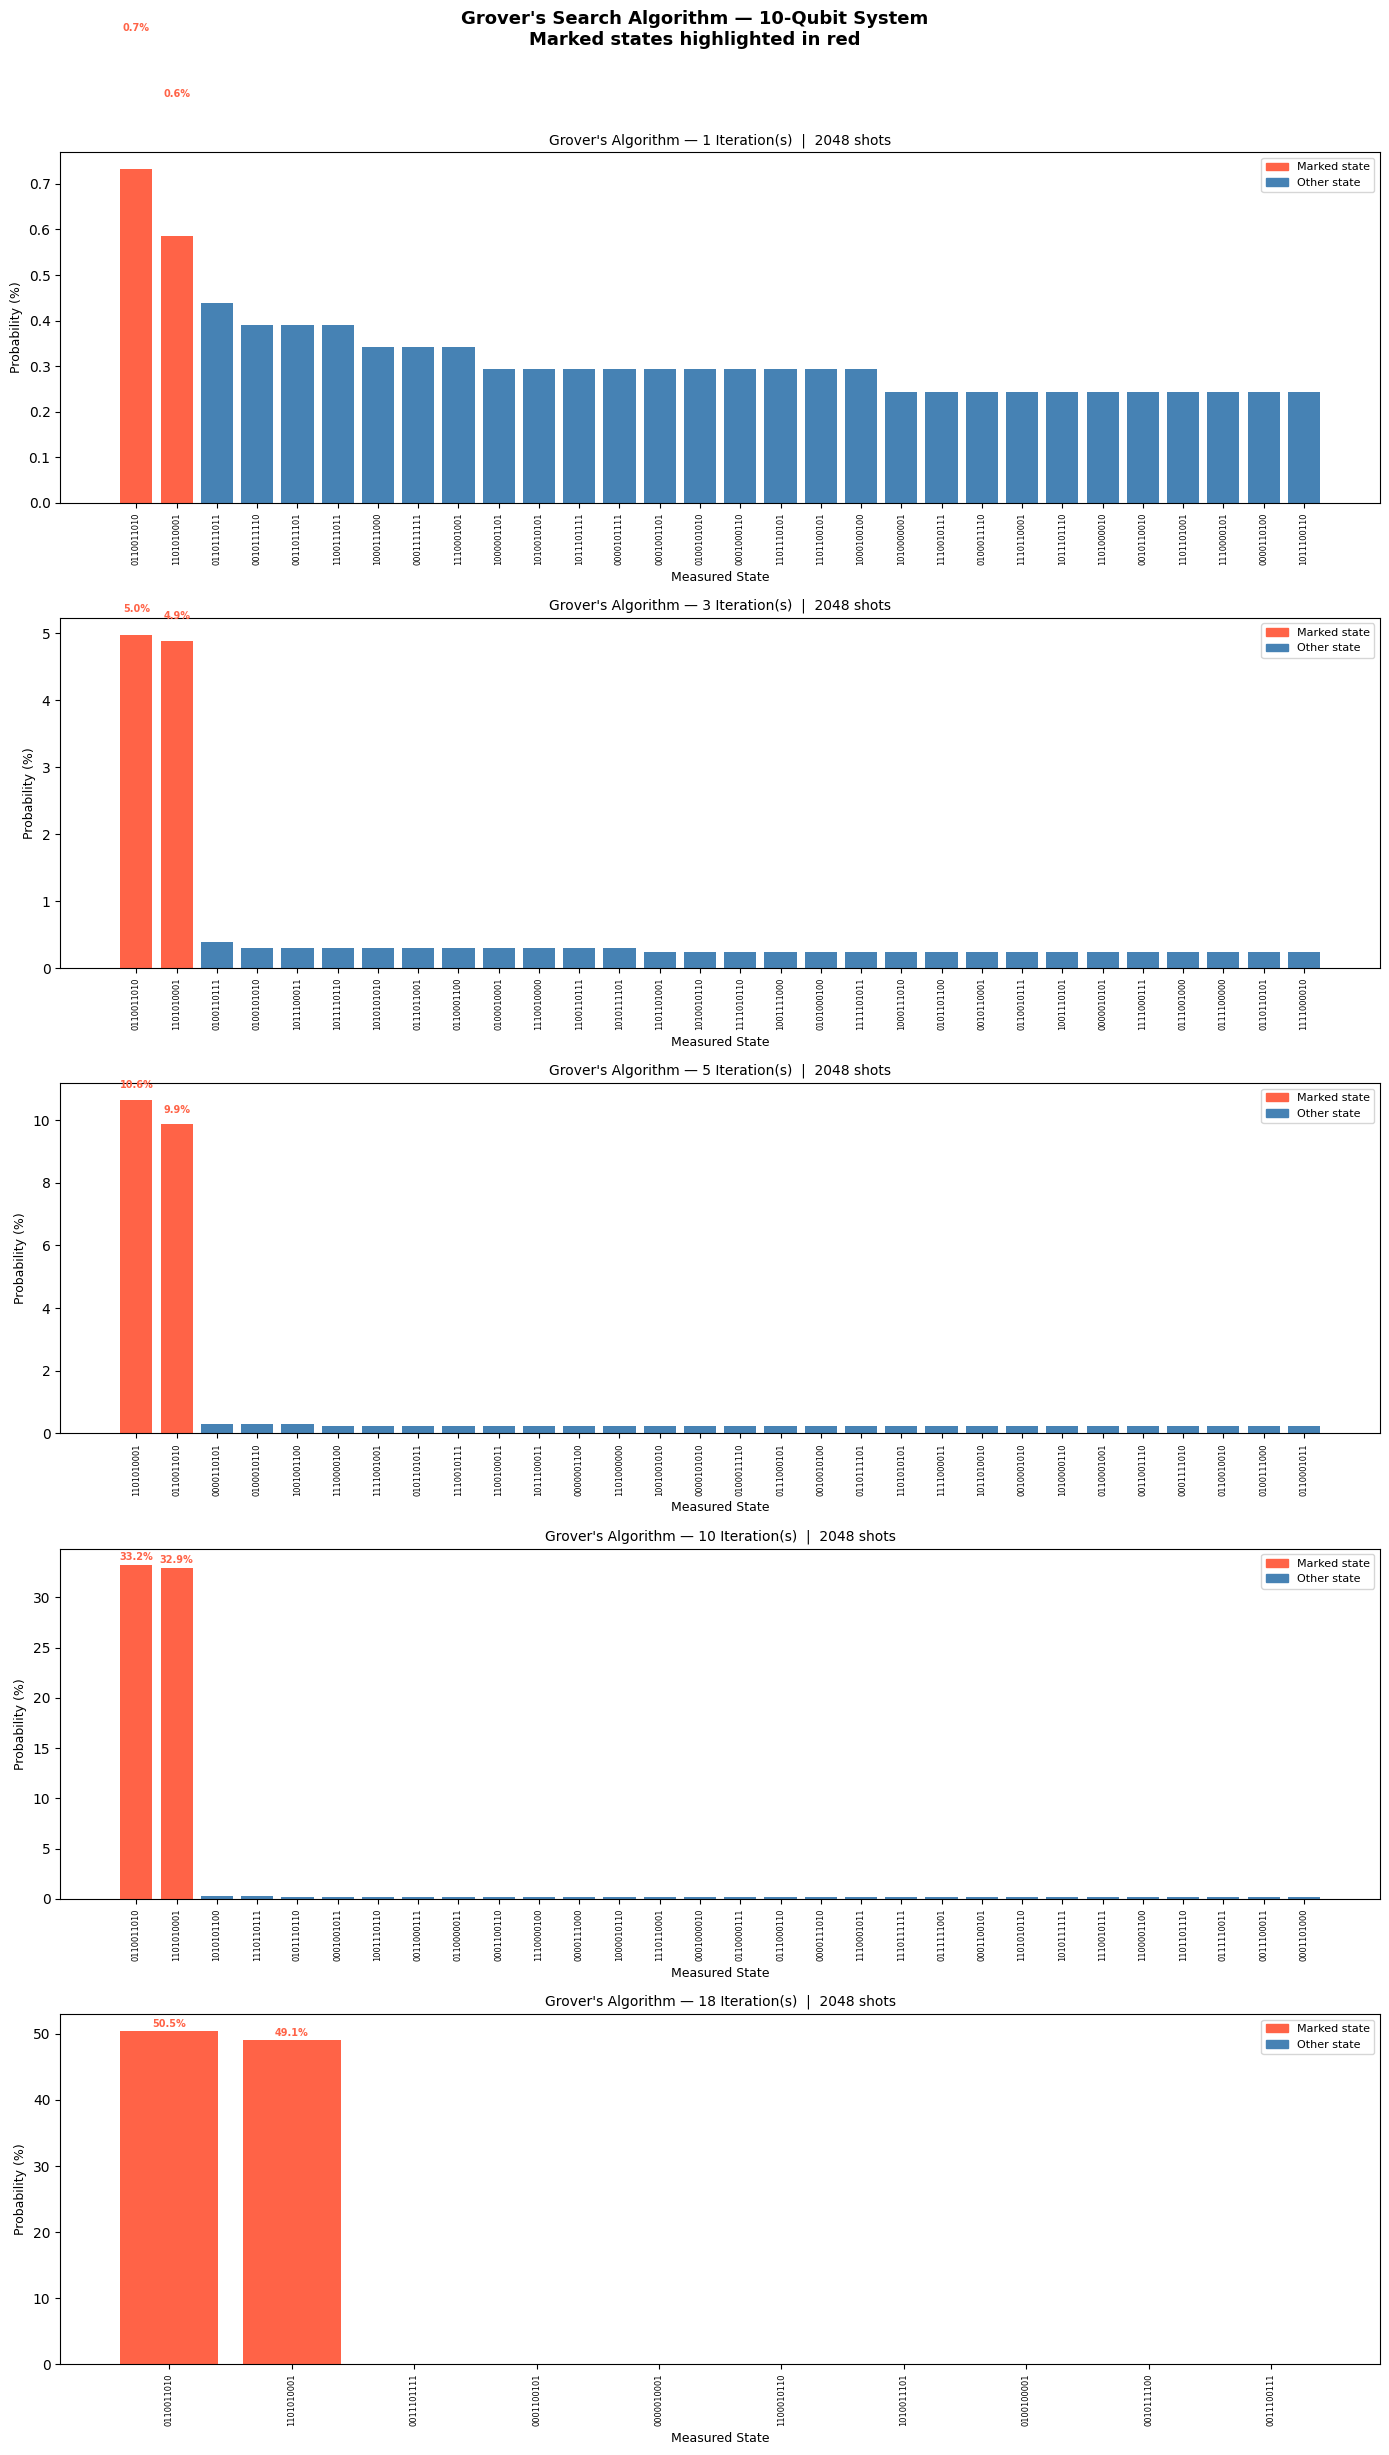

In [8]:
# ── Plot histograms ───────────────────────────────────────────────
fig, axes = plt.subplots(len(iteration_counts), 1,
                         figsize=(14, 5 * len(iteration_counts)))
if len(iteration_counts) == 1:
    axes = [axes]

for ax, k in zip(axes, iteration_counts):
    counts = all_counts[k]
    top30  = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:30]
    labels = [x[0] for x in top30]
    values = [x[1] / SHOTS * 100 for x in top30]
    colors = ["tomato" if lbl in targets else "steelblue" for lbl in labels]

    bars = ax.bar(labels, values, color=colors)
    ax.set_xlabel("Measured State", fontsize=9)
    ax.set_ylabel("Probability (%)", fontsize=9)
    ax.set_title(f"Grover's Algorithm — {k} Iteration(s)  |  {SHOTS} shots",
                 fontsize=10)
    ax.tick_params(axis="x", labelrotation=90, labelsize=6)

    for bar, label, val in zip(bars, labels, values):
        if label in targets:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f"{val:.1f}%",
                    ha="center", va="bottom",
                    fontsize=7, color="tomato", fontweight="bold")

    ax.legend(handles=[
        Patch(color="tomato",    label="Marked state"),
        Patch(color="steelblue", label="Other state"),
    ], fontsize=8)

fig.suptitle("Grover's Search Algorithm — 10-Qubit System\n"
             "Marked states highlighted in red",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

In [9]:
# ── Summary table ─────────────────────────────────────────────────
print(f"{'Iterations':>12}  {'P(0110011010)':>15}  {'P(1101010001)':>15}  {'P(both)':>10}")
print("-" * 60)
for k, counts in all_counts.items():
    p0 = counts.get("0110011010", 0) / SHOTS * 100
    p1 = counts.get("1101010001", 0) / SHOTS * 100
    print(f"{k:>12}  {p0:>14.1f}%  {p1:>14.1f}%  {p0+p1:>9.1f}%")

  Iterations    P(0110011010)    P(1101010001)     P(both)
------------------------------------------------------------
           1             0.7%             0.6%        1.3%
           3             5.0%             4.9%        9.9%
           5             9.9%            10.6%       20.5%
          10            33.2%            32.9%       66.1%
          18            50.5%            49.1%       99.6%
